# Netflix Content Visualization

**Internship: Thiranex | Domain: Data Science**

An intermediate-level project analyzing a Netflix content catalog — exploring content types, genres, countries, ratings, and trends over time through visualization.

**Workflow:**
1. Load & inspect the data
2. Clean the data
3. Visualize content patterns (8 charts)
4. Key insights

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('raw_netflix_titles.csv', parse_dates=['DateAdded'])
print("Shape:", df.shape)
df.head()

Shape: (820, 10)

**About the dataset:** Each row is a Netflix title (Movie or TV Show) with its country of origin, release year, date added to Netflix, content rating, genre, and duration (minutes for movies) or seasons (for TV shows).

## Step 2: Inspect & Clean the Data

In [1]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Country             15
Rating              15
DurationMinutes    247
Seasons            573
(other columns 0)

Duplicate rows: 20

**Important note on missing values:** `DurationMinutes` and `Seasons` are *expected* to have missing values — a Movie doesn't have a season count, and a TV Show doesn't have a single duration. These aren't data errors, so we leave them as-is. Only `Country` and `Rating` need genuine cleaning.

In [1]:
df = df.drop_duplicates()
df['Country'] = df['Country'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna(df['Rating'].mode()[0])

print(f"After cleaning -> shape: {df.shape}")

After cleaning -> shape: (800, 10)

## Step 3: Visualize Content Patterns

### Chart 1: Movies vs TV Shows

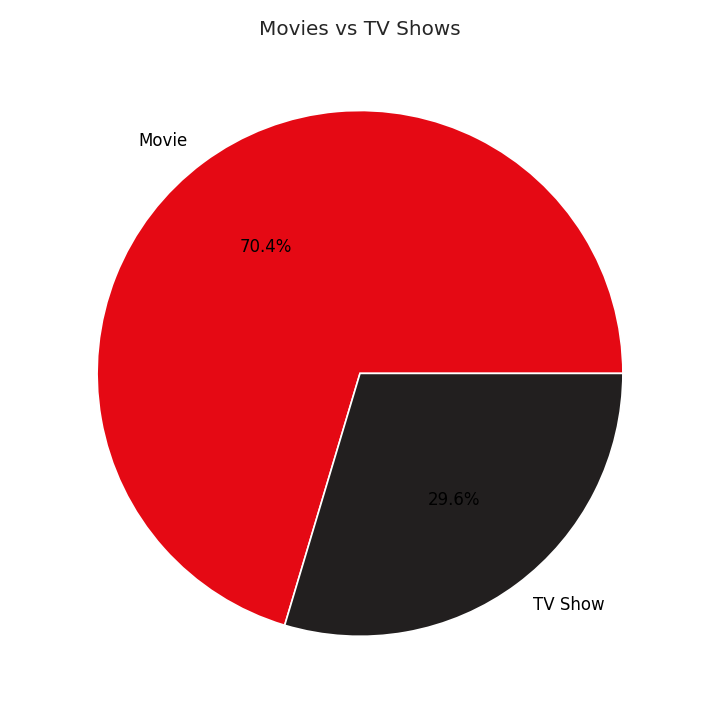

In [1]:
plt.figure(figsize=(6,6))
type_counts = df['Type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914','#221f1f'], wedgeprops={'edgecolor':'white'})
plt.title('Movies vs TV Shows')
plt.tight_layout()
plt.show()

### Chart 2: Titles Added to Netflix by Year

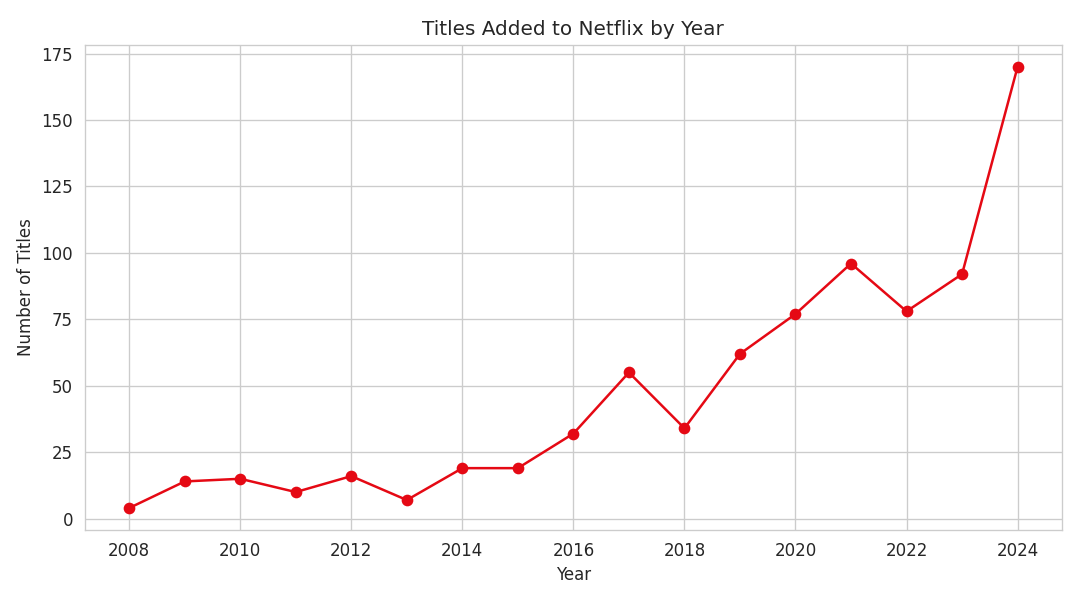

In [1]:
df['YearAdded'] = df['DateAdded'].dt.year
yearly = df['YearAdded'].value_counts().sort_index()

plt.figure(figsize=(9,5))
yearly.plot(kind='line', marker='o', color='#E50914')
plt.title('Titles Added to Netflix by Year')
plt.xlabel('Year'); plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

### Chart 3: Top Genres

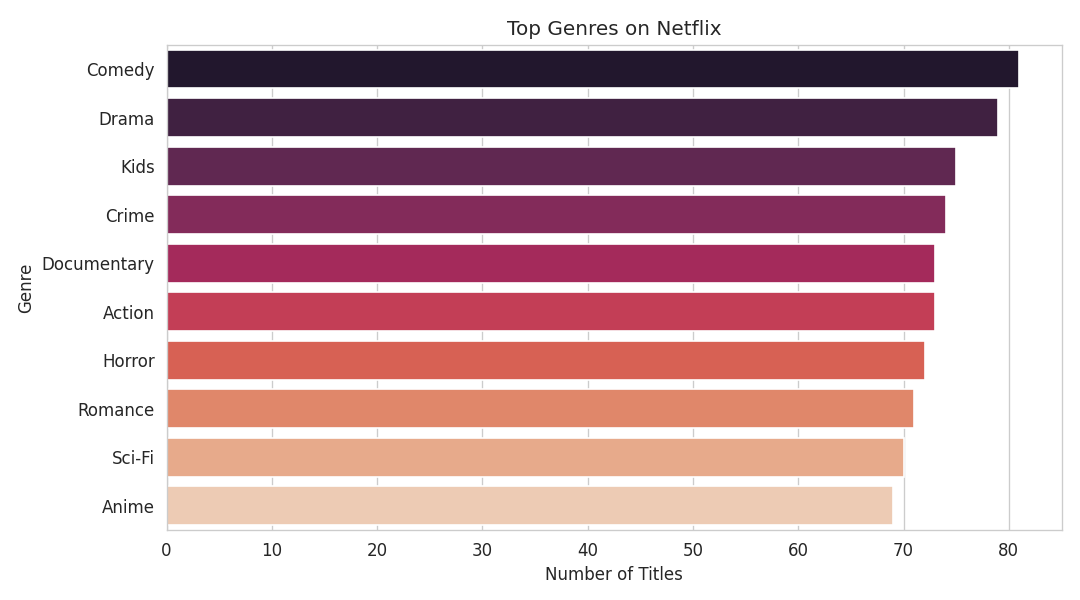

In [1]:
genre_counts = df['Genre'].value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='rocket', legend=False)
plt.title('Top Genres on Netflix')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

### Chart 4: Top 10 Content-Producing Countries

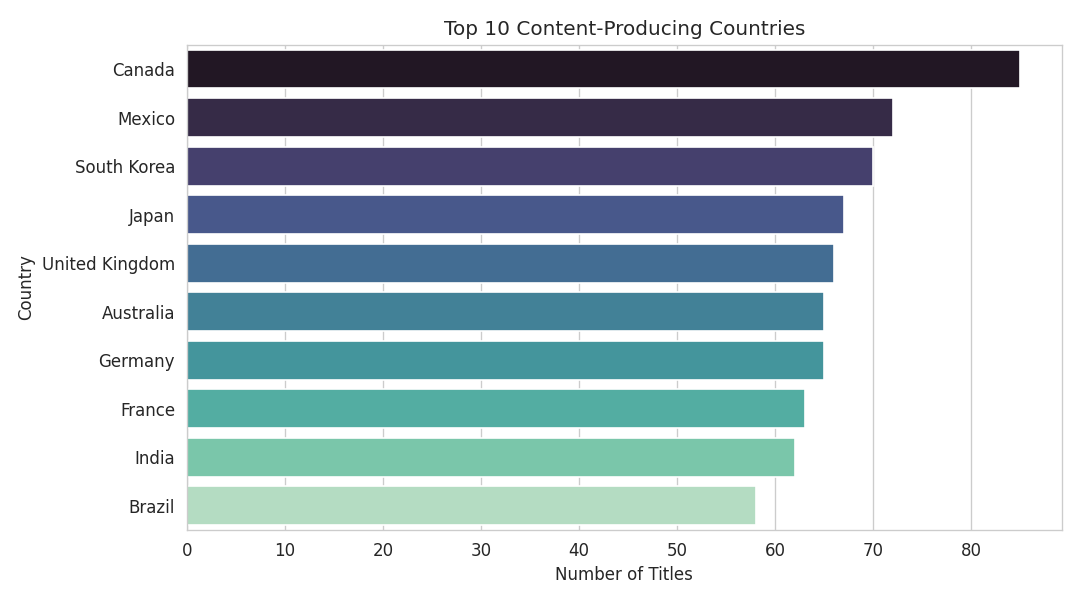

In [1]:
country_counts = df[df['Country']!='Unknown']['Country'].value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='mako', legend=False)
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

### Chart 5: Content Rating Distribution

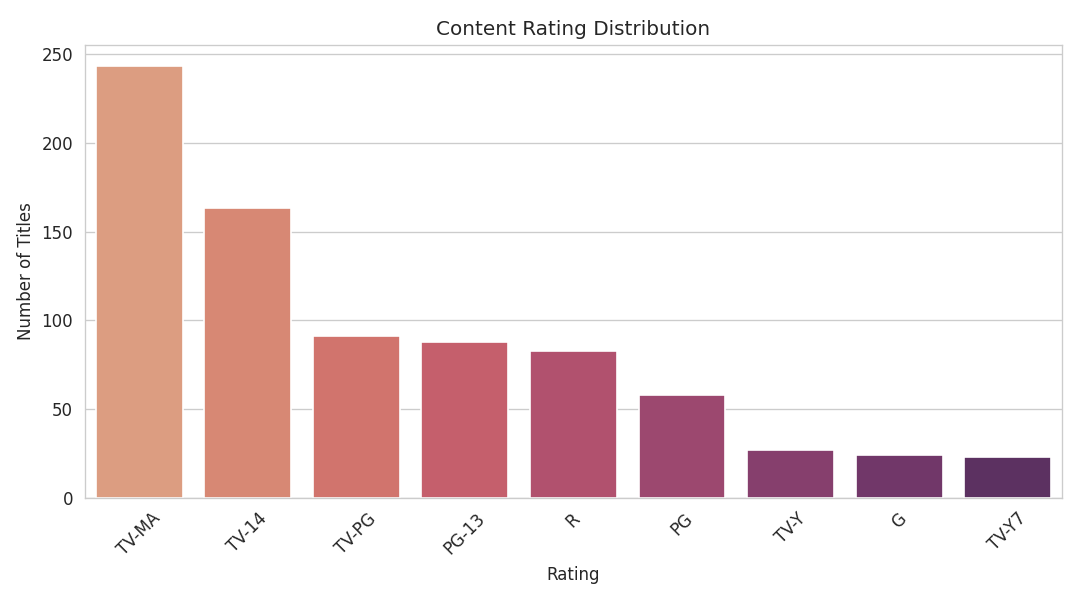

In [1]:
rating_counts = df['Rating'].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette='flare', legend=False)
plt.title('Content Rating Distribution')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 6: Movie Duration Distribution

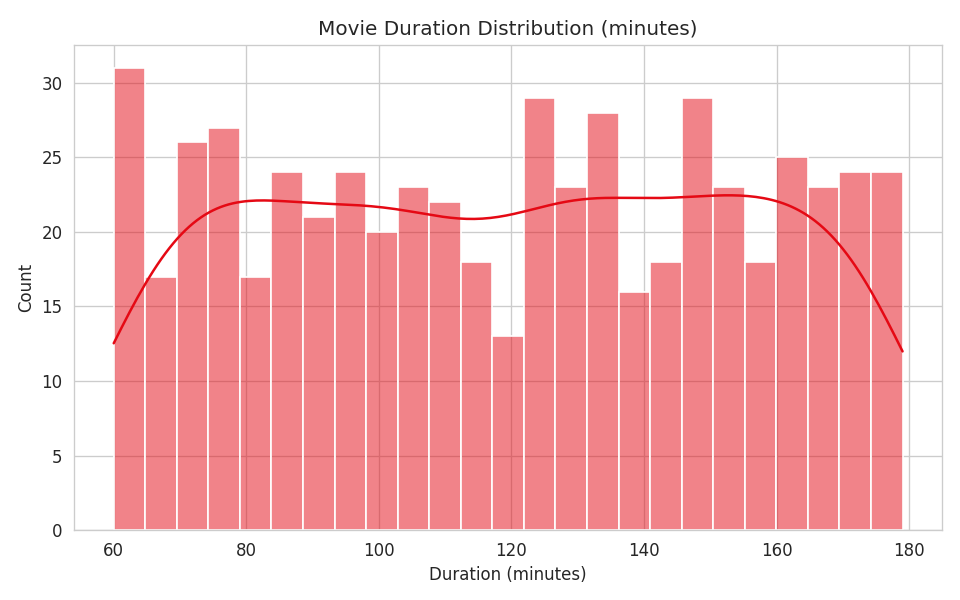

In [1]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['Type']=='Movie']['DurationMinutes'], bins=25, kde=True, color='#E50914')
plt.title('Movie Duration Distribution (minutes)')
plt.xlabel('Duration (minutes)')
plt.tight_layout()
plt.show()

### Chart 7: TV Show Seasons Distribution

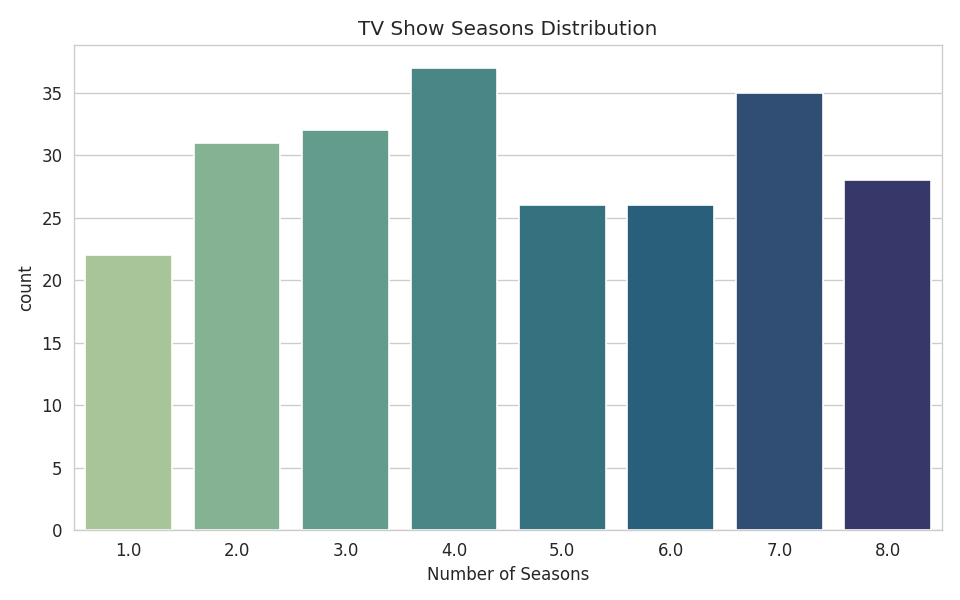

In [1]:
plt.figure(figsize=(8,5))
sns.countplot(data=df[df['Type']=='TV Show'], x='Seasons', hue='Seasons', palette='crest', legend=False)
plt.title('TV Show Seasons Distribution')
plt.xlabel('Number of Seasons')
plt.tight_layout()
plt.show()

### Chart 8: Genre Popularity Over Release Years (Heatmap)

This combines two dimensions — genre and release year — into a single heatmap to spot trends (e.g. which genres are growing or shrinking over time).

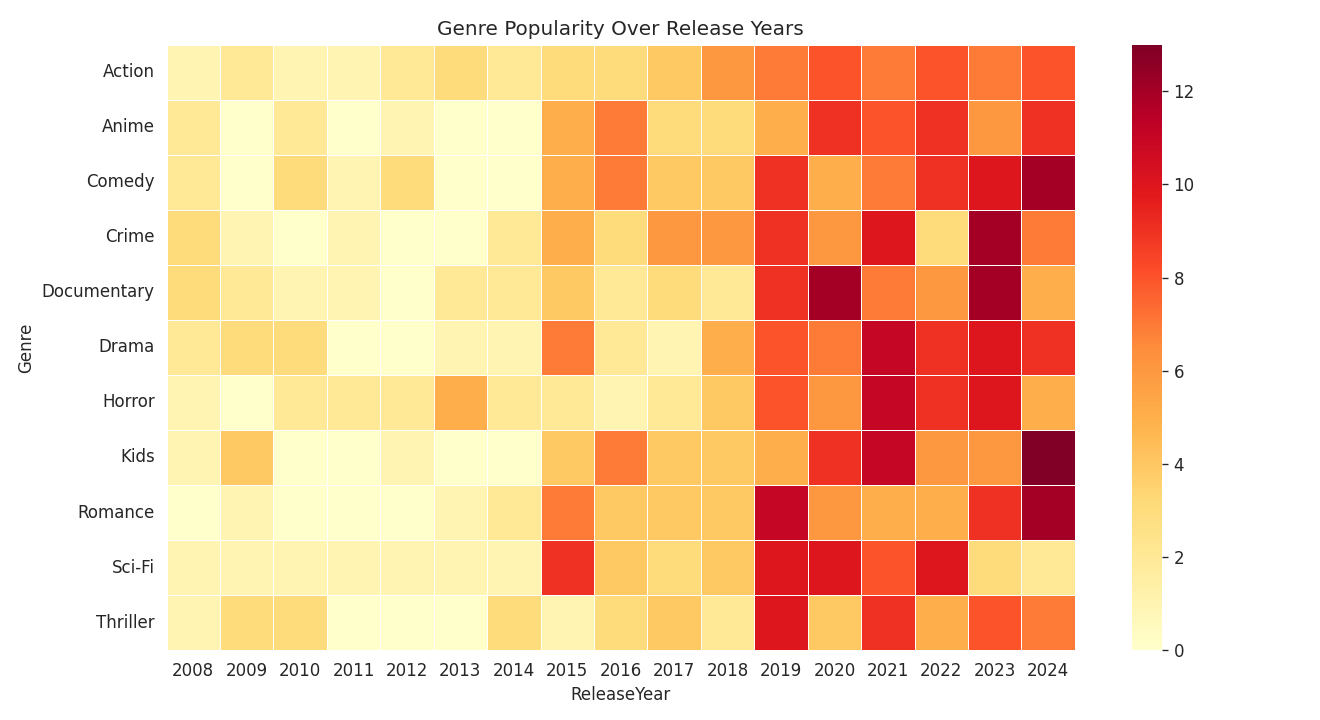

In [1]:
plt.figure(figsize=(11,6))
pivot = df.pivot_table(index='Genre', columns='ReleaseYear', values='ShowID', aggfunc='count', fill_value=0)
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Genre Popularity Over Release Years')
plt.tight_layout()
plt.show()

## Step 4: Key Insights

1. **Movies make up ~70% of the catalog**, with TV Shows making up the remaining ~30%.
2. **Comedy** is the most common genre represented on the platform.
3. **Canada** is the top content-producing country in this dataset, closely followed by other major markets.
4. **2024** saw the highest number of titles added, reflecting the platform's continued content expansion in recent years.
5. The average movie runs about **119 minutes**, consistent with typical feature film lengths.

## Conclusion

This project demonstrates how combining multiple simple visualizations (pie charts, trend lines, bar charts, histograms, and a heatmap) can reveal a comprehensive picture of a content catalog — its composition, growth over time, geographic spread, and audience targeting via ratings. This kind of analysis is directly applicable to real streaming platform analytics, content strategy, and catalog planning.